In [2]:
import pandas as pd
import glob

files = glob.glob('../data/raw/*.csv')
dfs = []
for f in files:
    df = pd.read_csv(f)
    df['source_file'] = f  # track which file each row came from
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141367 entries, 0 to 141366
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Arrival_Date    141367 non-null  object 
 1   Commodity       141367 non-null  object 
 2   Commodity_Code  141367 non-null  int64  
 3   District        141367 non-null  object 
 4   Grade           141367 non-null  object 
 5   Market          141367 non-null  object 
 6   Max_Price       141367 non-null  float64
 7   Min_Price       141367 non-null  float64
 8   Modal_Price     141367 non-null  float64
 9   State           141367 non-null  object 
 10  Variety         141367 non-null  object 
 11  source_file     141367 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 12.9+ MB


In [4]:
data.duplicated().sum()

0

In [5]:
zero_price_rows = (
    (data['Min_Price'] == 0) |
    (data['Max_Price'] == 0) |
    (data['Modal_Price'] == 0)
).sum()

print("Row where any price is  0:", zero_price_rows)

price_order_violations = (
    (data['Min_Price'] > data['Modal_Price']) |
    (data['Modal_Price'] > data['Max_Price'])
).sum()

print("Rows violating Min <= Modal <= Max:",price_order_violations)

Row where any price is  0: 1
Rows violating Min <= Modal <= Max: 0


In [6]:
data['Grade'].value_counts()

Grade
FAQ      124069
Local     17298
Name: count, dtype: int64

In [7]:
data['Variety'].value_counts()

Variety
Other         91810
Red           26218
Local         16064
Pole           2419
Unhali         1827
1st Sort       1099
2nd Sort        906
Hybrid          380
White           241
Chinchwad       152
Halva            80
Dry F.A.Q.       79
Fursungi         49
Onion            42
Nasik             1
Name: count, dtype: int64

In [8]:
data['Arrival _Date'] = pd.to_datetime(data['Arrival_Date'], errors='coerce')
data['Arrival_Date'].isna().sum()

0

In [9]:
faq = data[data['Grade']=='FAQ']
faq.groupby(['Market', 'Arrival_Date']).size().value_counts()

1    105722
2      7866
3       817
4        41
Name: count, dtype: int64

In [10]:
faq.groupby('Market')['Arrival_Date'].agg(['min', 'max', 'count'])

,min,max,count
Market,,,
Ahmednagar,01/01/2004,31/12/2020,1667
Akole,01/01/2017,31/12/2017,1268
Baramati,01/01/2011,31/12/2016,679
Chandvad,01/01/2004,31/12/2024,4039
Devala,01/01/2009,31/12/2024,4100
...,...,...,...
Umrane,01/01/2024,31/12/2024,832
Vaduj,01/02/2009,31/03/2008,30
Vaduj APMC,25/07/2026,25/07/2026,1


In [11]:
data['Arrival _Date'] = pd.to_datetime(data['Arrival_Date'], format='%d/%m//%Y', errors='coerce')
data['Arrival_Date'].isna().sum() 

0

In [12]:
faq.groupby('Market')['Arrival_Date'].agg(['min', 'max', 'count'])

,min,max,count
Market,,,
Ahmednagar,01/01/2004,31/12/2020,1667
Akole,01/01/2017,31/12/2017,1268
Baramati,01/01/2011,31/12/2016,679
Chandvad,01/01/2004,31/12/2024,4039
Devala,01/01/2009,31/12/2024,4100
...,...,...,...
Umrane,01/01/2024,31/12/2024,832
Vaduj,01/02/2009,31/03/2008,30
Vaduj APMC,25/07/2026,25/07/2026,1


In [13]:
faq['Market'].nunique()

78

In [14]:
faq['Market'].value_counts().head(10)

Market
Pune             5644
Lasalgaon        5578
Manmad           5031
Nasik            4699
Yeola            4659
Pimpalgaon       4624
Devala           4100
Chandvad         4039
Pune(Khadiki)    3985
Karad            3934
Name: count, dtype: int64

In [15]:
data.shape

(141367, 13)

In [ ]:
data['Arrival_Date'] = pd.to_datetime(data['Arrival_Date'], format='%d/%m/%Y', errors='coerce')
faq = data[data['Grade'] == 'FAQ']  
faq.groupby('Market')['Arrival_Date'].agg(['min','max','count'])

,min,max,count
Market,,,
Ahmednagar,2003-01-04,2025-01-23,1667
Akole,2005-04-15,2025-01-05,1268
Baramati,2004-07-14,2025-01-25,679
Chandvad,2003-01-30,2025-01-24,4039
Devala,2005-12-02,2025-01-24,4100
...,...,...,...
Umrane,2020-05-14,2025-01-22,832
Vaduj,2008-03-20,2009-03-15,30
Vaduj APMC,2026-07-25,2026-07-25,1


In [17]:
locked_markets = faq['Market'].value_counts().head(8).index.tolist()

In [18]:
daily_data = (data[data['Market'].isin(locked_markets) & (data['Grade'] == 'FAQ')]
              .groupby(['Market', 'Arrival_Date'], as_index=False)
              .median(numeric_only=True)
              )

In [19]:
daily_data.shape

(34139, 6)

In [20]:
daily_data.groupby('Market')['Arrival_Date'].agg(['min','max','count'])

,min,max,count
Market,,,
Chandvad,2003-01-30,2025-01-24,3625
Devala,2005-12-02,2025-01-24,3301
Lasalgaon,2002-08-06,2025-01-25,4444
Manmad,2002-12-02,2025-11-03,4223
Nasik,2002-04-01,2025-01-24,4453
Pimpalgaon,2002-08-19,2025-01-25,3953
Pune,2001-03-30,2025-01-24,5643
Yeola,2003-02-07,2025-01-25,4497


In [21]:
daily_data[daily_data['Market'] == 'Manmad'].sort_values('Arrival_Date').tail(10)

,Market,Arrival_Date,Commodity_Code,Max_Price,Min_Price,Modal_Price
15583,Manmad,2025-01-22,23.0,2233.5,630.0,1950.0
15584,Manmad,2025-01-23,23.0,2676.0,500.0,2100.0
15585,Manmad,2025-01-24,23.0,2835.0,500.0,2200.0
15586,Manmad,2025-01-25,23.0,2550.0,400.0,2150.0
15587,Manmad,2025-04-26,23.0,1280.0,400.0,1000.0
15588,Manmad,2025-06-19,23.0,1610.0,200.0,1400.0
15589,Manmad,2025-07-03,23.0,1652.0,500.0,1400.0
15590,Manmad,2025-08-21,23.0,1651.0,400.0,1400.0
15591,Manmad,2025-08-30,23.0,1480.0,300.0,1320.0
15592,Manmad,2025-11-03,23.0,1701.0,300.0,1500.0


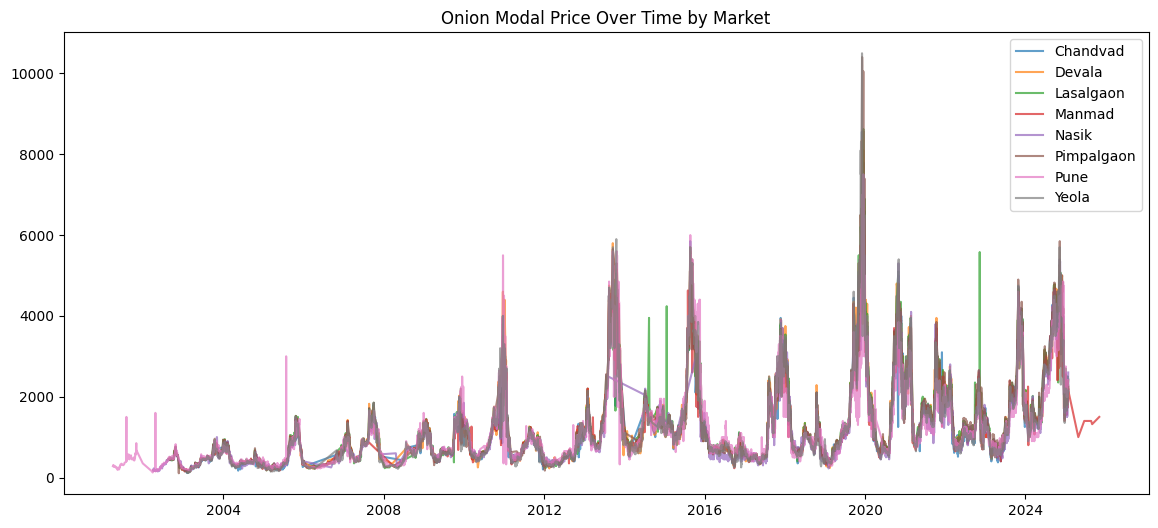

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (14,6))
for market in daily_data['Market'].unique():
    subset = daily_data[daily_data['Market'] == market].sort_values('Arrival_Date')
    ax.plot(subset['Arrival_Date'], subset['Modal_Price'], label = market, alpha=0.7)
ax.legend()
ax.set_title('Onion Modal Price Over Time by Market')
plt.show()


In [23]:
pune = daily_data[daily_data['Market'] == 'Pune'].sort_values('Arrival_Date')
pune[(pune['Arrival_Date'] >= '2002-01-01') & (pune['Arrival_Date'] <= '2002-12-31')]

,Market,Arrival_Date,Commodity_Code,Max_Price,Min_Price,Modal_Price
24077,Pune,2002-03-26,23.0,180.0,100.0,140.0
24078,Pune,2002-03-27,23.0,150.0,100.0,125.0
24079,Pune,2002-03-29,23.0,220.0,150.0,185.0
24080,Pune,2002-03-31,23.0,210.0,120.0,165.0
24081,Pune,2002-04-02,23.0,230.0,150.0,190.0
...,...,...,...,...,...,...
24222,Pune,2002-12-15,23.0,350.0,150.0,250.0
24223,Pune,2002-12-16,23.0,350.0,150.0,250.0
24224,Pune,2002-12-17,23.0,400.0,150.0,275.0
24225,Pune,2002-12-18,23.0,400.0,150.0,275.0


In [24]:
pune_2002 = pune[(pune['Arrival_Date'] >= '2002-01-01') & (pune['Arrival_Date'] <= '2002-12-31')]
pune_2002.sort_values('Modal_Price', ascending=False).head(10)

,Market,Arrival_Date,Commodity_Code,Max_Price,Min_Price,Modal_Price
24089,Pune,2002-04-21,23.0,2200.0,1000.0,1600.0
24206,Pune,2002-10-22,23.0,950.0,700.0,825.0
24203,Pune,2002-10-18,23.0,800.0,650.0,725.0
24204,Pune,2002-10-20,23.0,850.0,600.0,725.0
24207,Pune,2002-10-23,23.0,800.0,600.0,700.0
24208,Pune,2002-10-24,23.0,800.0,600.0,700.0
24205,Pune,2002-10-21,23.0,850.0,550.0,700.0
24212,Pune,2002-10-30,23.0,800.0,550.0,675.0
24213,Pune,2002-10-31,23.0,800.0,500.0,650.0
24217,Pune,2002-11-05,23.0,750.0,500.0,625.0


In [25]:
spike_date = pune_2002.sort_values('Modal_Price', ascending=False).iloc[0]['Arrival_Date']
pune[(pune['Arrival_Date'] >= spike_date - pd.Timedelta(days=10)) & (pune['Arrival_Date'] <= spike_date + pd.Timedelta(days=10))]

,Market,Arrival_Date,Commodity_Code,Max_Price,Min_Price,Modal_Price
24085,Pune,2002-04-11,23.0,220.0,150.0,185.0
24086,Pune,2002-04-17,23.0,230.0,150.0,190.0
24087,Pune,2002-04-18,23.0,200.0,120.0,160.0
24088,Pune,2002-04-19,23.0,200.0,130.0,165.0
24089,Pune,2002-04-21,23.0,2200.0,1000.0,1600.0
24090,Pune,2002-04-23,23.0,200.0,100.0,150.0
24091,Pune,2002-04-24,23.0,220.0,150.0,185.0
24092,Pune,2002-04-25,23.0,200.0,150.0,175.0
24093,Pune,2002-04-26,23.0,240.0,150.0,195.0
24094,Pune,2002-04-28,23.0,250.0,150.0,200.0


In [26]:
daily_data.sort_values('Modal_Price', ascending=False).head(20)

,Market,Arrival_Date,Commodity_Code,Max_Price,Min_Price,Modal_Price
33077,Yeola,2019-12-04,23.0,12991.0,3001.0,10500.0
22631,Pimpalgaon,2019-12-05,23.0,12371.5,3050.0,10406.0
22632,Pimpalgaon,2019-12-06,23.0,13075.5,3250.0,10197.5
22640,Pimpalgaon,2019-12-16,23.0,11877.5,6777.5,10053.0
22630,Pimpalgaon,2019-12-04,23.0,11550.0,4000.0,9926.0
22629,Pimpalgaon,2019-12-03,23.0,11402.0,3250.0,9800.5
33078,Yeola,2019-12-05,23.0,12400.0,2750.0,9250.0
33076,Yeola,2019-12-02,23.0,12500.0,2000.0,9000.0
10062,Lasalgaon,2019-12-16,23.0,10099.0,2000.0,8625.0
2413,Chandvad,2019-12-03,23.0,9900.5,5385.0,8560.0


In [29]:
dauly_data = daily_data.sort_values(
    ['Market', 'Arrival_Date']
).reset_index(drop=True)

In [30]:
daily_data['Rolling_Median'] = (
    daily_data.groupby('Market')['Modal_Price']
    .transform(
        lambda x: x.rolling(window=7, min_periods=3).median()
    )
)

In [31]:
daily_data['Price_Ratio'] = (
    daily_data['Modal_Price'] / daily_data['Rolling_Median']
)

In [32]:
daily_data['Next_Price'] = (
    daily_data.groupby('Market')['Modal_Price'].shift(-1)
)

In [33]:
daily_data['Next_Rolling_Median'] = (
    daily_data.groupby('Market')['Rolling_Median'].shift(-1)
)

In [34]:
daily_data['Next_Price_Ratio'] = (
    daily_data['Next_Price'] / daily_data['Next_Rolling_Median']
)

In [35]:
extreme = (
    (daily_data['Price_Ratio'] > 5) | (daily_data['Price_Ratio'] < 0.2)
)

In [36]:
reverted = daily_data['Next_Price_Ratio'].between(0.8, 1.2)

In [37]:
daily_data['Likely_Error'] = extreme & reverted

In [38]:
daily_data['Likely_Error'].sum()

4

In [40]:
# Should be True (Pune's April 2002 spike)
daily_data[(daily_data['Market']=='Pune') & (daily_data['Arrival_Date']=='2002-04-21')][['Market','Arrival_Date','Modal_Price','Price_Ratio','Next_Price_Ratio','Likely_Error']]


,Market,Arrival_Date,Modal_Price,Price_Ratio,Next_Price_Ratio,Likely_Error
24089,Pune,2002-04-21,1600.0,8.648649,0.833333,True


In [41]:
# Should be False (Dec 2019 real crisis, e.g. Yeola)
daily_data[(daily_data['Market']=='Yeola') & (daily_data['Arrival_Date']=='2019-12-04')][['Market','Arrival_Date','Modal_Price','Price_Ratio','Next_Price_Ratio','Likely_Error']]

,Market,Arrival_Date,Modal_Price,Price_Ratio,Next_Price_Ratio,Likely_Error
33077,Yeola,2019-12-04,10500.0,1.458333,1.284722,False


In [44]:
daily_data = daily_data[~daily_data['Likely_Error']].reset_index(drop=True)

In [45]:
daily_data.shape

(34135, 12)

In [46]:
daily_data.to_csv('../data/processed/onion_cleaned.csv', index=False)